## Predictive Analysis of Term Deposit Subscriptions in Portuguese Banking

### AIM: The purpose of this analysis is to explore and understand customer behavior from direct marketing campaigns conducted by a Portuguese banking institution. The campaigns were conducted via phone calls with the objective of promoting term deposit subscriptions.This data analysis aims to identify patterns, trends, and relationships among customer demographics, financial status, campaign attributes, and macroeconomic indicators that influence customer decisions.

In [132]:
import pandas as pd  # Importing Libraries
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [133]:
df=pd.read_csv(r'C:\Users\rohit\Desktop\Datamites Data\Portugese bank Data\bank-additional\bank-additional-full.csv') #importing CSV file

In [134]:
df.head(5) # visualizing top 5 rows

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [135]:
df.info()  # analysing dataset with its columns,null value and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [136]:
for col in df.describe().columns: #Analyzing each numerical columns with its unique values
    print(col)
    print(df[col].unique())
    print('-'*50)

age
[56 57 37 40 45 59 41 24 25 29 35 54 46 50 39 30 55 49 34 52 58 32 38 44
 42 60 53 47 51 48 33 31 43 36 28 27 26 22 23 20 21 61 19 18 70 66 76 67
 73 88 95 77 68 75 63 80 62 65 72 82 64 71 69 78 85 79 83 81 74 17 87 91
 86 98 94 84 92 89]
--------------------------------------------------
duration
[ 261  149  226 ... 1246 1556 1868]
--------------------------------------------------
campaign
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 19 18 23 14 22 25 16 17 15 20 56
 39 35 42 28 26 27 32 21 24 29 31 30 41 37 40 33 34 43]
--------------------------------------------------
pdays
[999   6   4   3   5   1   0  10   7   8   9  11   2  12  13  14  15  16
  21  17  18  22  25  26  19  27  20]
--------------------------------------------------
previous
[0 1 2 3 4 5 6 7]
--------------------------------------------------
emp.var.rate
[ 1.1  1.4 -0.1 -0.2 -1.8 -2.9 -3.4 -3.  -1.7 -1.1]
--------------------------------------------------
cons.price.idx
[93.994 94.465 93.918 93.444 93.798 93.2   9

In [137]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

<Axes: >

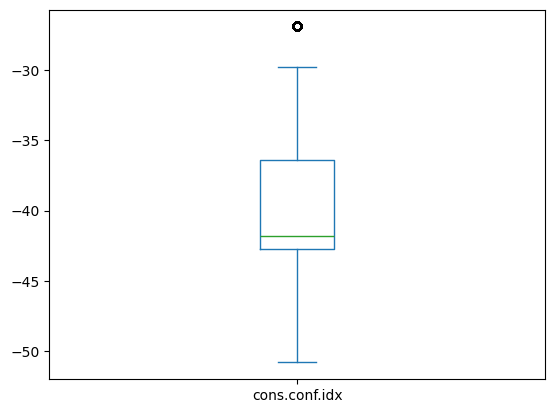

In [138]:
df['cons.conf.idx'].plot(kind='box') #visualizing the column in boxplot to find the outlier 

In [139]:
df=df[df['cons.conf.idx']<-28] ##  removing outlier

<Axes: >

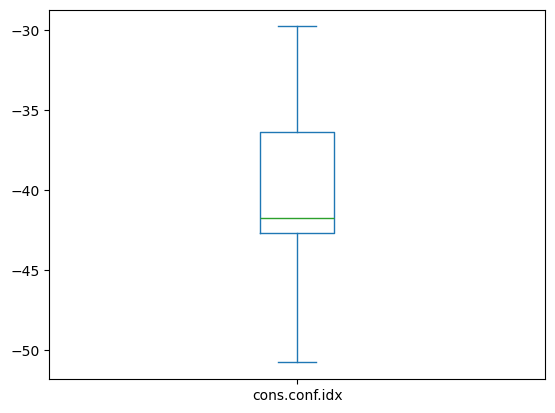

In [140]:
df['cons.conf.idx'].plot(kind='box')

In [141]:
for col in df.describe(include=object).columns: #Analyzing each column with its unique values for object type data
    print(col)
    print(df[col].unique())
    print('-'*50)

job
['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
--------------------------------------------------
marital
['married' 'single' 'divorced' 'unknown']
--------------------------------------------------
education
['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
--------------------------------------------------
default
['no' 'unknown' 'yes']
--------------------------------------------------
housing
['no' 'yes' 'unknown']
--------------------------------------------------
loan
['no' 'yes' 'unknown']
--------------------------------------------------
contact
['telephone' 'cellular']
--------------------------------------------------
month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
--------------------------------------------------
day_of_week
['mon' 'tue' 'wed' 'thu' 'fri']
----------------------------

## Analysing the data through Visualization

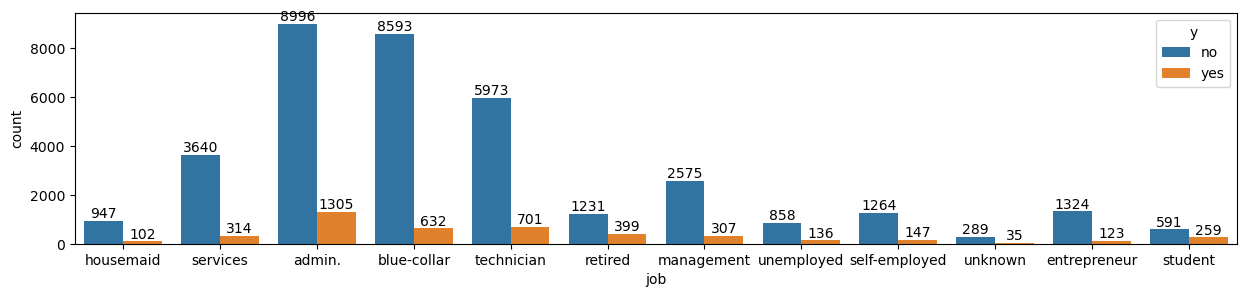

In [142]:
plt.figure(figsize=(15,3))  # visualizing in countplot to figure out the impact of job type on taking the term deposit.
axj=sns.countplot(x=df['job'],data=df,hue=df['y'])
for bars in axj.containers:
     axj.bar_label(bars)


In [143]:
##student ,retired and admin have higher chance to take term plan

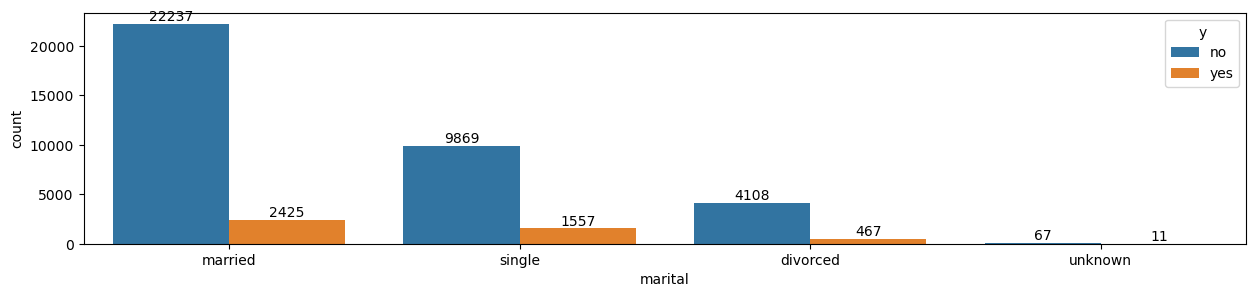

In [144]:
plt.figure(figsize=(15,3))  # visualizing in countplot to figure out the impact of marital status on taking the term deposit.
axm=sns.countplot(x=df['marital'],data=df,hue=df['y'])
for bars in axm.containers:
     axm.bar_label(bars)

In [145]:
# Single have higher chances to take term deposit

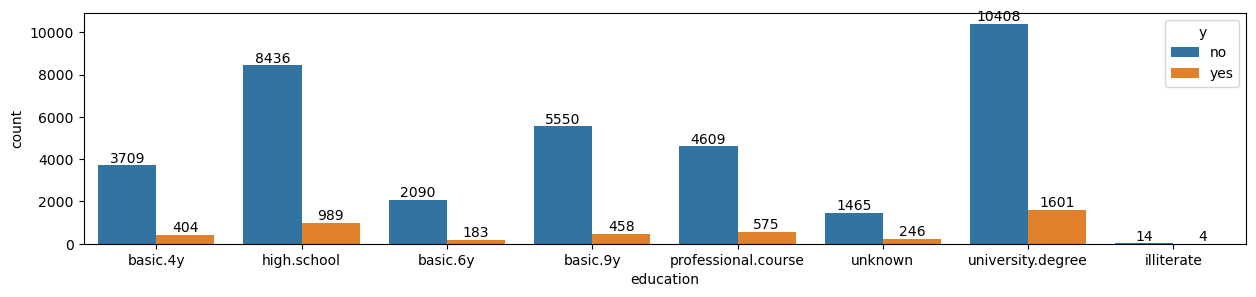

In [146]:
plt.figure(figsize=(15,3))  # visualizing in countlpot to figure out the impact of qualifiaction on taking the term deposit.
axe=sns.countplot(x=df['education'],data=df,hue=df['y'])
for bars in axe.containers:
     axe.bar_label(bars)

In [147]:
##high school and university degree have higher chances to take term deposit

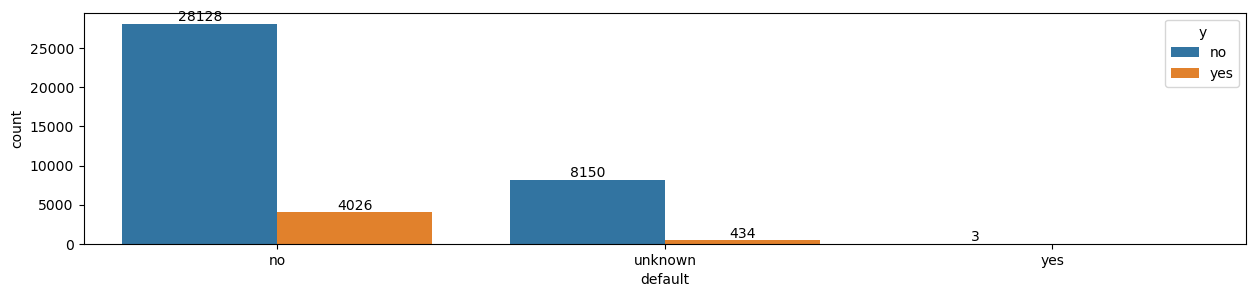

In [148]:
plt.figure(figsize=(15,3)) # visualizing in countplot to figure out the impact of credit default on taking the term deposit.
axd=sns.countplot(x=df['default'],data=df,hue=df['y'])
for bars in axd.containers:
     axd.bar_label(bars)

In [149]:
## Customer with No credit default have higher chances to take term deposit

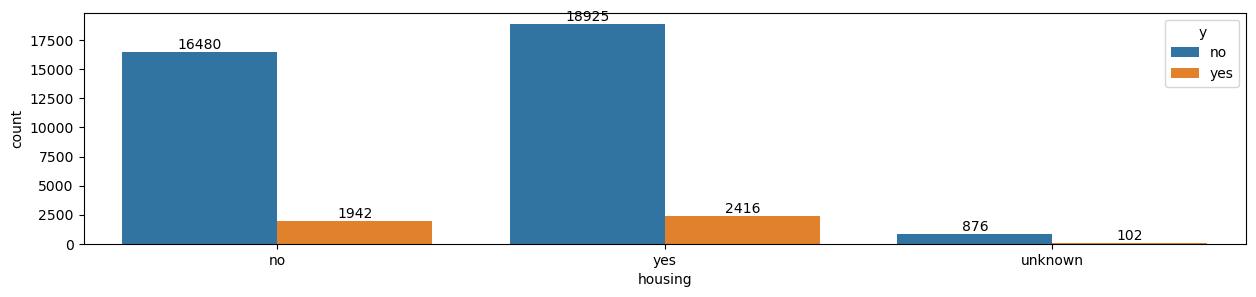

In [150]:
plt.figure(figsize=(15,3)) # visualizing in countplot to figure out the impact of housing loan on taking the term deposit.
axd=sns.countplot(x=df['housing'],data=df,hue=df['y'])
for bars in axd.containers:
     axd.bar_label(bars)

In [151]:
## Housing loan status does not effect much on client bahaviour to take term deposit

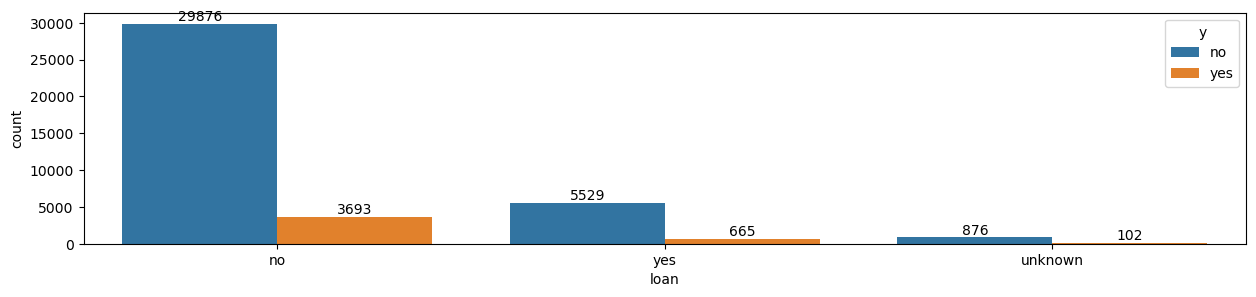

In [152]:
plt.figure(figsize=(15,3)) # visualizing in countplot to figure out the impact of personal loan on taking the term deposit.
axl=sns.countplot(x=df['loan'],data=df,hue=df['y'])
for bars in axl.containers:
     axl.bar_label(bars)

In [153]:
## Housing loan status does not effect much on client bahaviour to take term deposit.


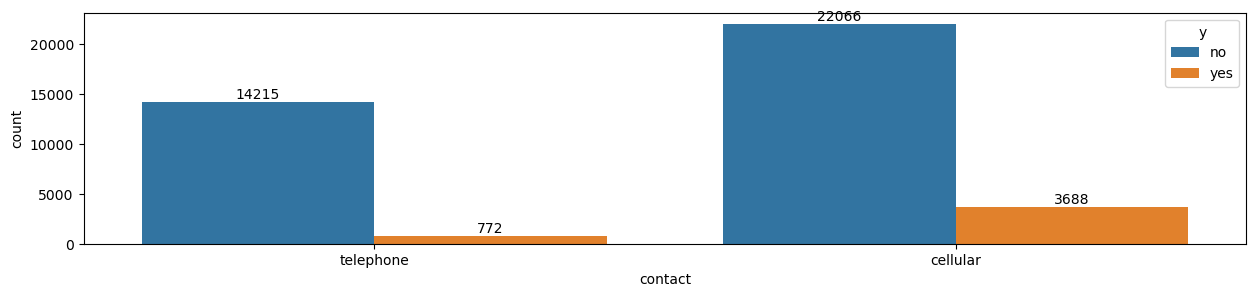

In [154]:
plt.figure(figsize=(15,3)) #visualizing in countplot to figure out the impact of contact method on taking the term deposit.
axc=sns.countplot(x=df['contact'],data=df,hue=df['y'])
for bars in axc.containers:
     axc.bar_label(bars)

In [155]:
## Contact through cellular phone effect much on client bahaviour to take term deposit.


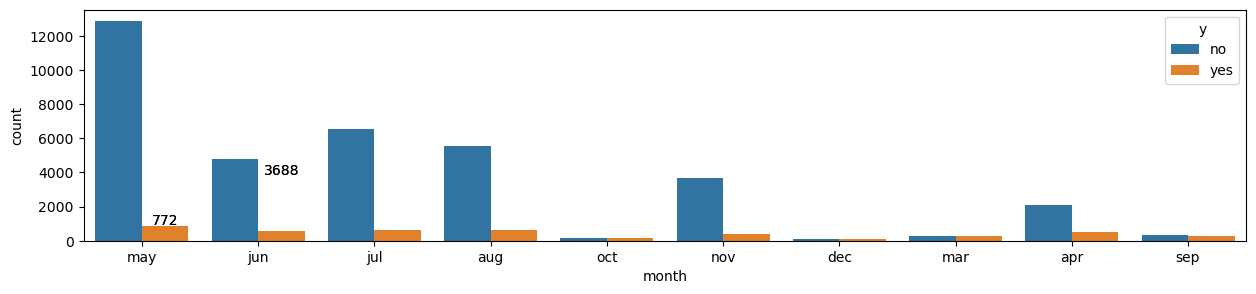

In [156]:
plt.figure(figsize=(15,3)) #visualizing in countplot to figure out the iimpact of month on taking the term deposit.
axm=sns.countplot(x=df['month'],data=df,hue=df['y'])
for bar in axm.containers:
     axm.bar_label(bars)

In [157]:
## Contact on monthwise does not effect much on client bahaviour to take term deposit.


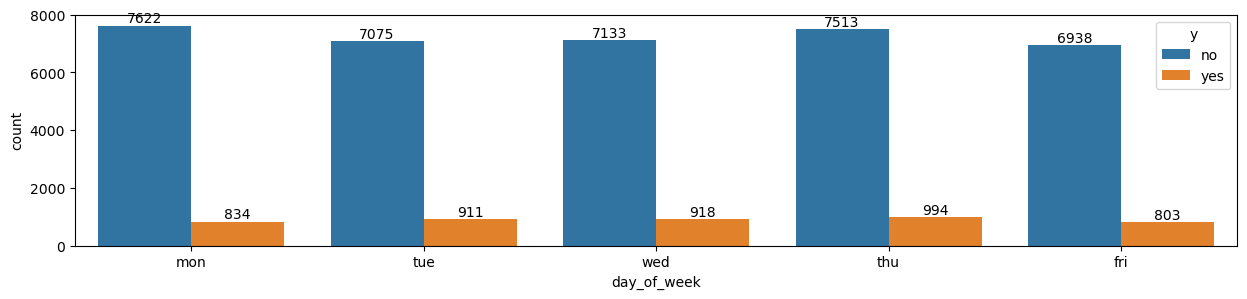

In [158]:
plt.figure(figsize=(15,3)) #visualizing in countlpot to figure out the impact of calling on daywise on taking the term deposit.
axdw=sns.countplot(x=df['day_of_week'],data=df,hue=df['y'])
for bars in axdw.containers:
     axdw.bar_label(bars)

In [159]:
## Contact on daywise having same effect on client bahaviour to take term deposit.


In [160]:
dfa=df[df['age']<85]

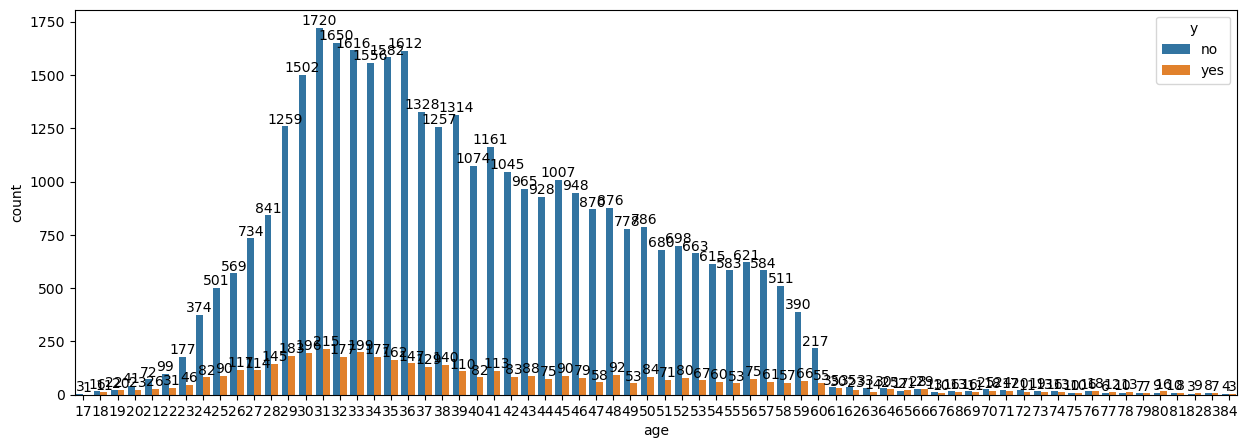

In [161]:
plt.figure(figsize=(15,5)) #visualizing in countplot to figure out the impact of age on taking the term deposit.
axa=sns.countplot(x=dfa['age'],data=dfa,hue=dfa['y'])
for bars in axa.containers:
     axa.bar_label(bars)

In [162]:
 ## Customer betweeen 60 to 80 years of age having high chance to take term deposit.


In [163]:
dfc=df[df['campaign']<15]

<Axes: xlabel='campaign', ylabel='Count'>

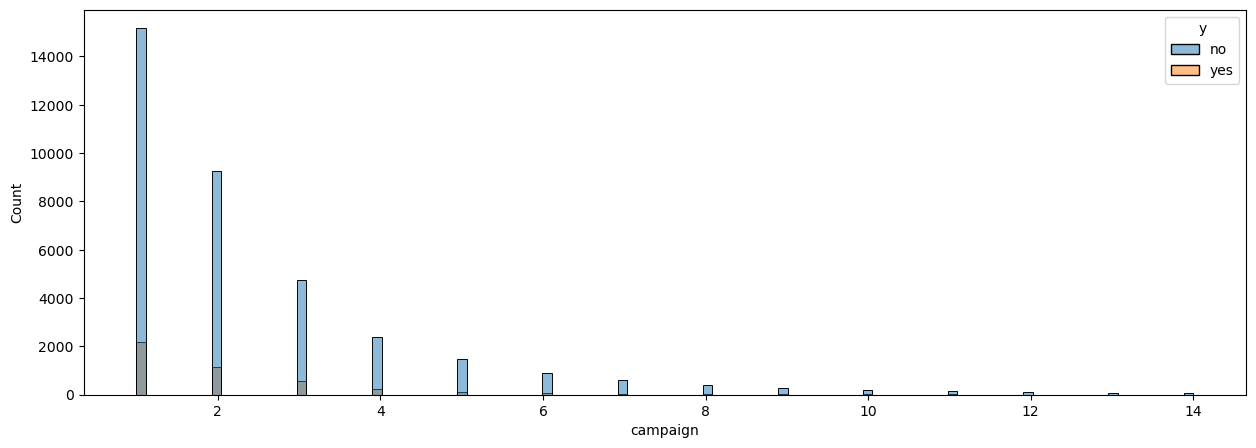

In [164]:
plt.figure(figsize=(15,5)) #visualizing in countplot to figure out the impact of campaigning on taking the term deposit.
sns.histplot(x=dfc['campaign'],data=dfc,hue=dfc['y'])


In [165]:
## Campaigning does not affect much on client bahaviour to take term deposit.

In [166]:
dfd=df[df['duration']<1400]

<Axes: xlabel='duration', ylabel='Count'>

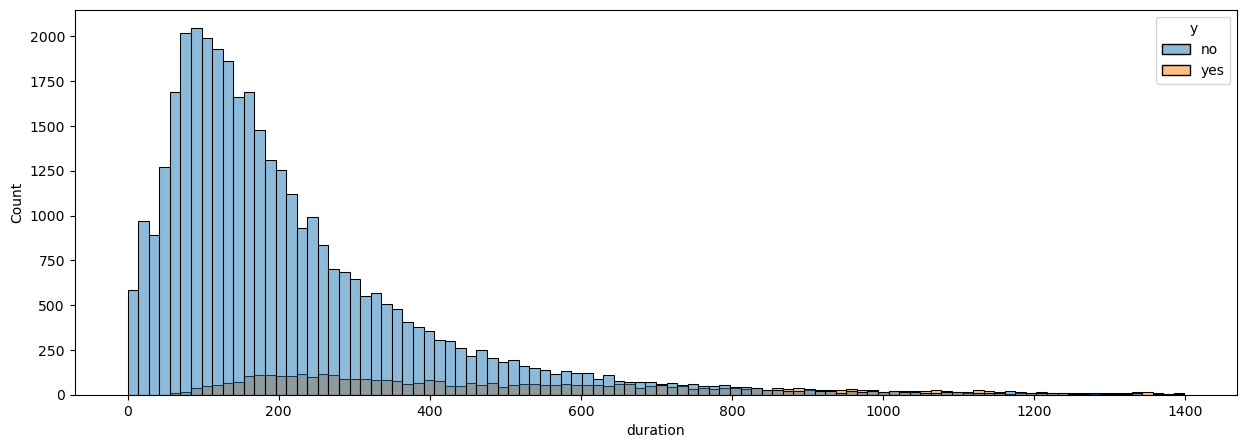

In [167]:
plt.figure(figsize=(15,5)) # #visualizing in countplot to figure out the impact of duration of calling on taking the term deposit.
sns.histplot(x=dfd['duration'],data=dfd,hue=dfd['y'],bins=100)


In [169]:
 ## calling betweeen 500 to 1200 seconds having high chance of customer to take term deposit.


In [170]:
dfpd=df[df['pdays']<27]   ####999 is eliminated as it means client is not contacted previously

<Axes: xlabel='pdays', ylabel='count'>

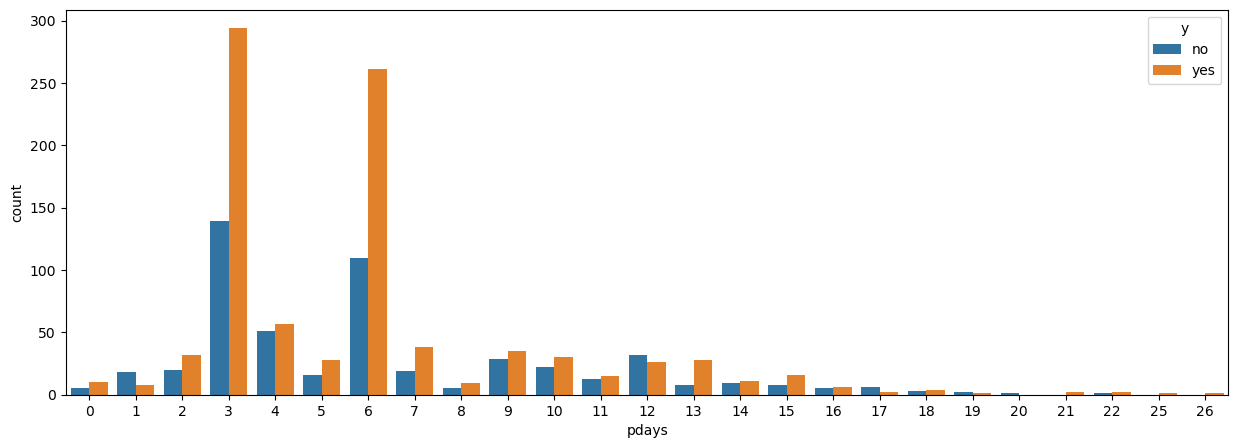

In [171]:
plt.figure(figsize=(15,5)) #visualizing in countplot to figure out number of days for previous calling having what impact on taking the term deposit.
sns.countplot(x=dfpd['pdays'],data=dfpd,hue=dfpd['y'])


In [172]:
## Number of days for previous calling does not affect much on client bahaviour to take term deposit.

<Axes: xlabel='nr.employed', ylabel='Count'>

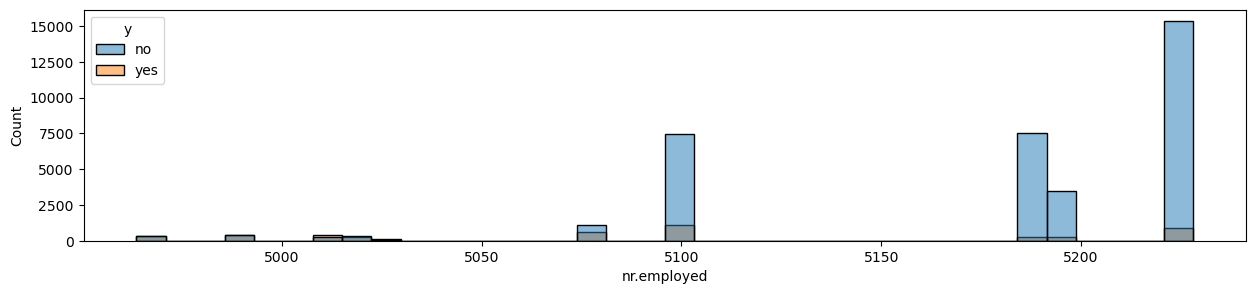

In [173]:
plt.figure(figsize=(15,3)) 
sns.histplot(x=df['nr.employed'],data=df,hue=df['y'])


<Axes: xlabel='previous', ylabel='Count'>

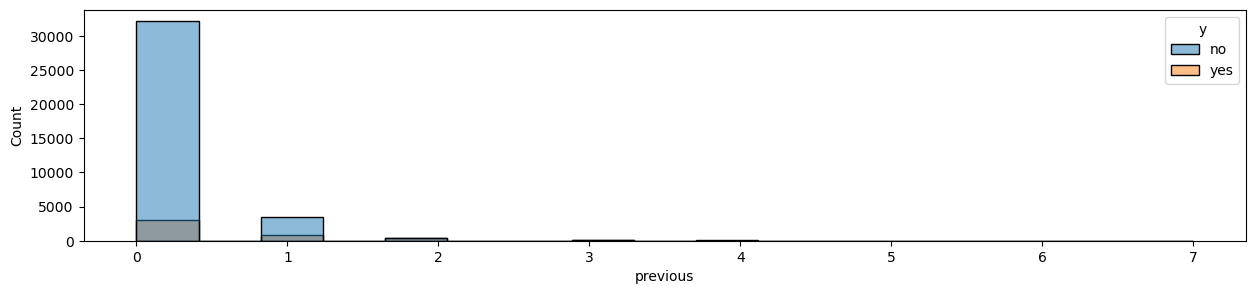

In [174]:
plt.figure(figsize=(15,3)) #visualizing in countplot to figure out number of days for previous calling having not much impact on taking the term deposit.
sns.histplot(x=df['previous'],data=df,hue=df['y'])

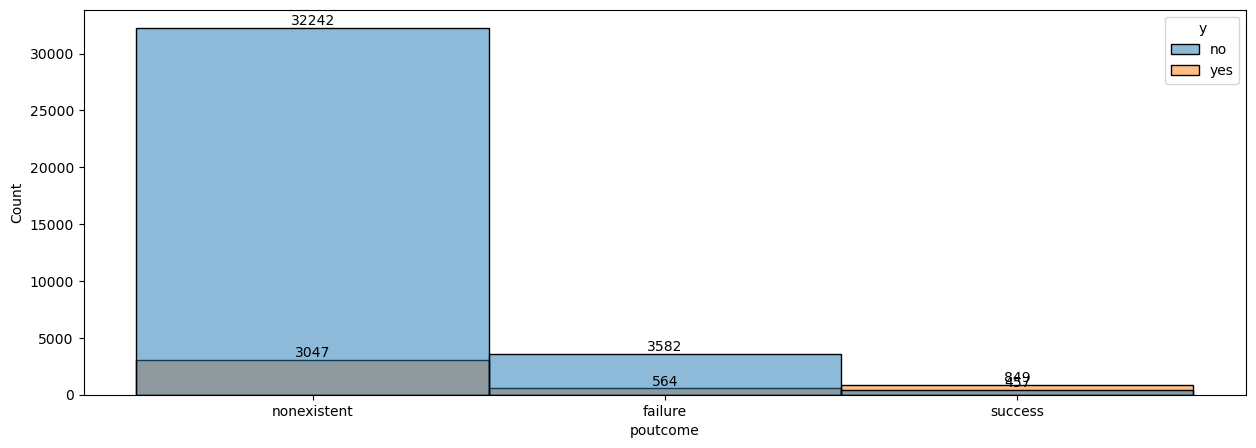

In [175]:
plt.figure(figsize=(15,5)) #visualizing in countplot to figure out the result of previous calling outcome on taking the term deposit.
axpo=sns.histplot(x=df['poutcome'],data=df,hue=df['y'])
for bars in axpo.containers:
     axpo.bar_label(bars)

In [ ]:
#Customers with a successful previous campaign outcome have the highest subscription probability

<Axes: xlabel='emp.var.rate', ylabel='Count'>

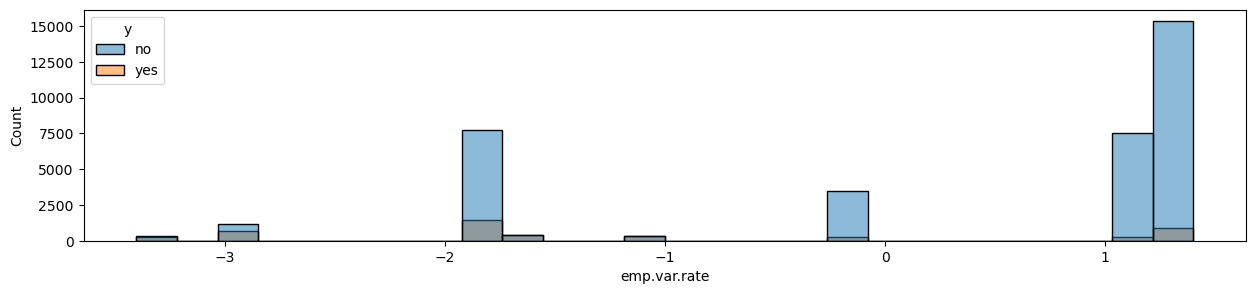

In [176]:
plt.figure(figsize=(15,3)) #visualizing in countplot to figure out the impact of emp.var.rate on taking the term deposit not showing much effect on customer decision to take term deposits
sns.histplot(x=df['emp.var.rate'],data=df,hue=df['y'])

<Axes: xlabel='cons.price.idx', ylabel='Count'>

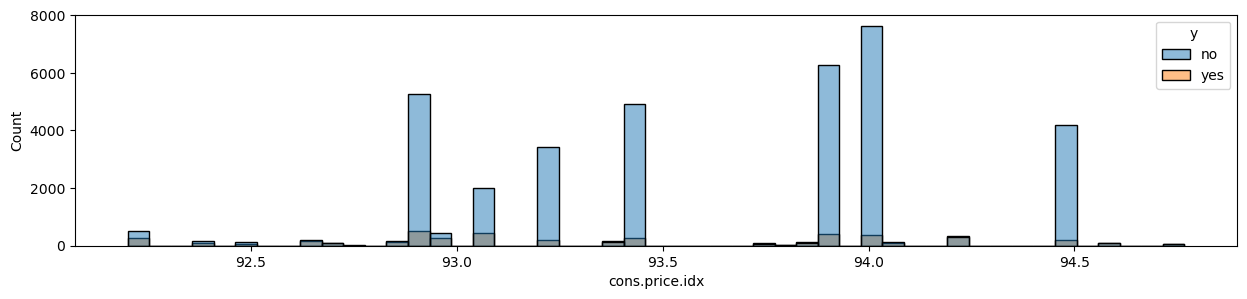

In [177]:
plt.figure(figsize=(15,3))  ##  not showing much effect on customer decision to take term deposits
sns.histplot(x=df['cons.price.idx'],data=df,hue=df['y'])

<Axes: xlabel='cons.conf.idx', ylabel='Count'>

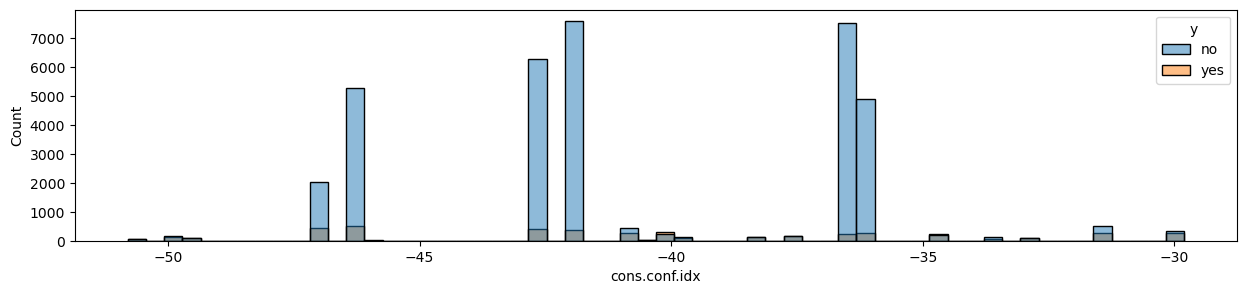

In [178]:
plt.figure(figsize=(15,3)) #not showing much effect on customer decision to take term deposits
sns.histplot(x=df['cons.conf.idx'],data=df,hue=df['y'])

<Axes: xlabel='euribor3m', ylabel='Count'>

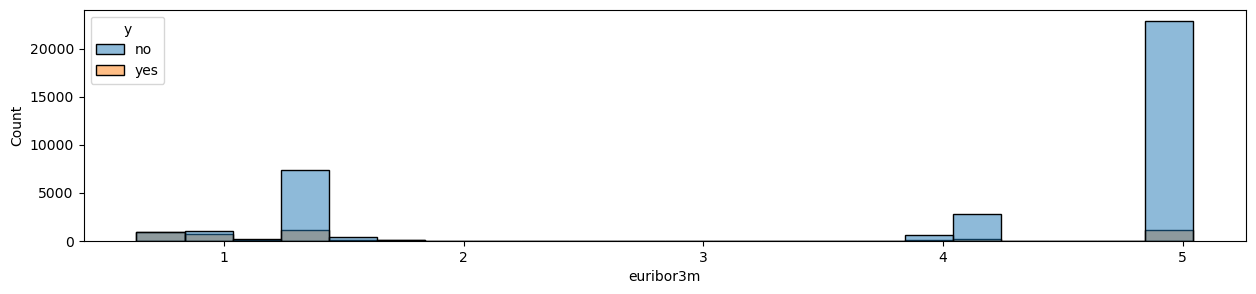

In [179]:
plt.figure(figsize=(15,3)) #showing effect on customer decision to take term deposits,lower Euribor rates are associated with higher subscription rates
sns.histplot(x=df['euribor3m'],data=df,hue=df['y'])

### Older and retired customers, along with students, management professionals, and university-educated individuals, show higher term deposit subscription rates, particularly those without credit defaults. Campaign effectiveness improves with cellular communication and limited contact attempts, while excessive follow-ups reduce customer interest. Additionally, successful previous campaign outcomes and lower Euribor interest rates are strongly associated with increased subscription likelihood.


In [180]:
for col in df.describe(include=object).columns:
    print(col)
    print(df[col].unique())
    print('-'*50)

job
['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
--------------------------------------------------
marital
['married' 'single' 'divorced' 'unknown']
--------------------------------------------------
education
['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
--------------------------------------------------
default
['no' 'unknown' 'yes']
--------------------------------------------------
housing
['no' 'yes' 'unknown']
--------------------------------------------------
loan
['no' 'yes' 'unknown']
--------------------------------------------------
contact
['telephone' 'cellular']
--------------------------------------------------
month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
--------------------------------------------------
day_of_week
['mon' 'tue' 'wed' 'thu' 'fri']
----------------------------

### Encoding the values in numerical form using LabelEncoder as object type data can not be trained in machine learning model

In [181]:
df['marital'].value_counts()

marital
married     24662
single      11426
divorced     4575
unknown        78
Name: count, dtype: int64

In [182]:
df['marital']=df['marital'].replace('unknown','married')    

In [183]:
df['marital']=df['marital'].map({'single':'1','married':'2','divorced':'0'})

In [184]:
df['marital'].value_counts()

marital
2    24740
1    11426
0     4575
Name: count, dtype: int64

In [185]:
df['marital']=df['marital'].astype(int)

In [186]:
df['marital'].value_counts() ##single=1,married=2,divorced=0

marital
2    24740
1    11426
0     4575
Name: count, dtype: int64

In [187]:
df['job'].value_counts()

job
admin.           10301
blue-collar       9225
technician        6674
services          3954
management        2882
retired           1630
entrepreneur      1447
self-employed     1411
housemaid         1049
unemployed         994
student            850
unknown            324
Name: count, dtype: int64

In [188]:
df['job']=df['job'].replace('unknown','admin.') 

In [189]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [190]:
df['job']=le.fit_transform(df['job'])

In [191]:
df['job'].value_counts() 

job
0     10625
1      9225
9      6674
7      3954
4      2882
5      1630
2      1447
6      1411
3      1049
10      994
8       850
Name: count, dtype: int64

In [192]:
## admin.=0,blue-collar=1,technician=2,services=3,management=4,retired=5,entrepreneur=6,self-employed=7,housemaid=8,unemployed=9,student=10'''

In [193]:
df['education'].value_counts()


education
university.degree      12009
high.school             9425
basic.9y                6008
professional.course     5184
basic.4y                4113
basic.6y                2273
unknown                 1711
illiterate                18
Name: count, dtype: int64

In [194]:
df['education']=le.fit_transform(df['education'])

In [195]:
##basic.4y=0,basic.6y=1,basic.9y=2,high.school=3,illiterate=4,professional.course=5,university.degree=6,unknown=7

In [196]:
df['education'].value_counts()

education
6    12009
3     9425
2     6008
5     5184
0     4113
1     2273
7     1711
4       18
Name: count, dtype: int64

In [197]:
df['default'].value_counts()

default
no         32154
unknown     8584
yes            3
Name: count, dtype: int64

In [198]:
##df['default']=df['default'].map({'no':'0','yes':'1','unknown':'2'})     

In [199]:
##df['default']=df['default'].astype(int)

In [200]:
df['default'].value_counts()


default
no         32154
unknown     8584
yes            3
Name: count, dtype: int64

In [201]:
df['housing'].value_counts()

housing
yes        21341
no         18422
unknown      978
Name: count, dtype: int64

In [202]:
df['loan'].value_counts()

loan
no         33569
yes         6194
unknown      978
Name: count, dtype: int64

In [203]:
df['contact'].value_counts()

contact
cellular     25754
telephone    14987
Name: count, dtype: int64

In [204]:
df['month'].value_counts()

month
may    13769
jul     7174
aug     6178
jun     5318
nov     4101
apr     2632
sep      570
mar      546
oct      271
dec      182
Name: count, dtype: int64

In [205]:
df['day_of_week'].value_counts()

day_of_week
thu    8507
mon    8456
wed    8051
tue    7986
fri    7741
Name: count, dtype: int64

In [206]:
df['poutcome'].value_counts()

poutcome
nonexistent    35289
failure         4146
success         1306
Name: count, dtype: int64

In [207]:
df['y'].value_counts()

y
no     36281
yes     4460
Name: count, dtype: int64

In [208]:
df['default']=le.fit_transform(df['default']) ##no=0,unknown=1,yes=2 
df['housing']=le.fit_transform(df['housing']) ##no=0,unknown=1,yes=2 
df['loan']=le.fit_transform(df['loan']) ##no=0,unknown=1,yes=2 
df['contact']=le.fit_transform(df['contact']) ##cellular=0,telephone=1
df['month']=le.fit_transform(df['month']) ##may=6,jul=3,aug=1,jun=4,nov=7,apr=0,sep=9,mar=5,oct=8,dec=2
df['day_of_week']=le.fit_transform(df['day_of_week']) ##thu=2,mon=1,wed=4,tue=3,fri=0
df['poutcome']=le.fit_transform(df['poutcome']) ##nonexistent=1,failure=0,success =2
df['y']=le.fit_transform(df['y']) ##no=0,yes=1 

## Data cleaning and encoding completed

In [209]:
x=df.drop(['housing','loan','day_of_week','campaign','y'],axis=1)##housing,loan,day_of_week,campaign columns are deleted as they have no effect on outcome
y=df['y']

In [210]:
x.columns

Index(['age', 'job', 'marital', 'education', 'default', 'contact', 'month',
       'duration', 'pdays', 'previous', 'poutcome', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

In [211]:
from sklearn.model_selection import train_test_split  ## importing train_test_split model

In [212]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y) ##Segregate data for training and testing

In [213]:
len(x_train)

32592

## Importing different models, training them and finding Accuracy score.

In [214]:
from sklearn.linear_model import LinearRegression ## importing LinearRegression model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [215]:
model_lr=LinearRegression()
model_lr.fit(x_train,y_train)  ## training model


LinearRegression()

In [216]:
model_lr.score(x_test,y_test)  ## checking accuracy score

0.3481118838280687

In [217]:
y_pred=model_lr.predict(x_test)

In [218]:
from sklearn.tree import DecisionTreeClassifier ## importing DecisionTreeClassifier model
model_dt=DecisionTreeClassifier()
model_dt.fit(x_train,y_train) ## training model

DecisionTreeClassifier()

In [219]:
model_dt.score(x_test,y_test) ## checking accuracy score

0.8901705730764511

In [220]:
y_pred=model_dt.predict(x_test)  # pediction ooutput

In [221]:
accuracy_score(y_test,y_pred)  #Checking accuracy score on various precisions

0.8901705730764511

In [222]:
precision_score(y_test,y_pred)

0.4983425414364641

In [223]:
recall_score(y_test,y_pred)

0.5056053811659192

In [224]:
f1_score(y_test,y_pred)

0.5019476905954369

In [225]:
from sklearn.model_selection import cross_val_score  ## importing cross_val_score model
model_lr_cv=cross_val_score(DecisionTreeClassifier(),x,y,cv=5)
model_lr_cv.mean()

np.float64(0.4461244284696786)

In [226]:
from sklearn.ensemble import BaggingClassifier ## importing BaggingClassifier model
model_bag=BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=100,max_samples=0.8,oob_score=True,random_state=10)
model_bag.fit(x_train,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=0.8,
                  n_estimators=100, oob_score=True, random_state=10)

In [227]:
model_bag.score(x_test,y_test)

0.9177813228617008

In [228]:
y_pred=model_bag.predict(x_test)


In [229]:
f1_score(y_test,y_pred)

0.5899632802937577

In [230]:
accuracy_score(y_test,y_pred)


0.9177813228617008

In [231]:
precision_score(y_test,y_pred)


0.6495956873315364

In [232]:
recall_score(y_test,y_pred)


0.5403587443946188

In [233]:
from sklearn.ensemble import RandomForestClassifier ## importing RandomForestClassifier model
cv_rf=cross_val_score(RandomForestClassifier(n_estimators=10),x,y,cv=5)


In [234]:
cv_rf.mean()

np.float64(0.44919267209827174)

In [235]:
from sklearn.ensemble import RandomForestClassifier
rf_cv=cross_val_score(RandomForestClassifier(),x,y,cv=4)
rf_cv.mean()

np.float64(0.31804392882469523)

In [236]:
from sklearn.ensemble import GradientBoostingClassifier  ## importing GradientBoostingClassifier model
model_gb = GradientBoostingClassifier(n_estimators=5) ## object creation
model_gb.fit(x_train,y_train)

GradientBoostingClassifier(n_estimators=5)

In [237]:
model_gb.score(x_test,y_test)


0.8905387164069211

In [238]:
model_gb.predict(x_test)

array([0, 0, 0, ..., 0, 0, 0])

## Hyperparameter tuning and finding best parameter for each model

In [261]:
pip install xgboost 


Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [240]:
from xgboost import XGBClassifier ## importing XGBClassifier model
from sklearn.model_selection import RandomizedSearchCV ## importing RandomizedSearchCV model

In [241]:
param_grid = {'gamma': [0,0.1,0.2,0.4,0.8,1.6,3.2,6.4,12.8,25.6,51.2,102.4, 200],# minimum loss reduction required to do further split
              'learning_rate': [0.01, 0.03, 0.06, 0.1, 0.15, 0.2, 0.25, 0.300000012, 0.4, 0.5, 0.6, 0.7], # slow down the learning process
              'max_depth': [5,6,7,8,9,10,11,12,13,14],
              'n_estimators': [50,65,80,100,115,130,150],
              'reg_alpha':[0,0.1,0.2,0.4,0.8,1.6,3.2,6.4,12.8,25.6,51.2,102.4,200],# regularization parameter used to prevent overfitting
              'reg_lambda':[0,0.1,0.2,0.4,0.8,1.6,3.2,6.4,12.8,25.6,51.2,102.4,200]

             }

In [242]:

XGB=XGBClassifier(random_state=42,verbosity=2)
#tree_cv = GridSearchCV(XGB, param_grid, scoring="accuracy", n_jobs=-1, verbose=1, cv=3)


In [243]:
rcv= RandomizedSearchCV(estimator=XGB, scoring='f1',param_distributions=param_grid, n_iter=10, cv=5, # assisgning various parameters to create the model
                               verbose=2, random_state=42, n_jobs=-1,return_train_score=False)

In [244]:
rcv.fit(x_train,y_train)##training data on randomsearch cv

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[03:02:42] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (32592, 16, 521472).


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                                  102.4, 200],
                                        'learning_rate': [0.01, 0.03, 0.06, 0.1,
                                                          0.15, 0.2, 0.25,
                                                          0.300000012, 0.4, 0.5,
                                                          0.6, 0.7],
                                        'max_depth': [5, 6, 7, 8, 9, 10, 11, 12,
                                                      13, 14],
                                        'n_estimators': [50, 65, 80, 100, 115,
                                                         130, 150],
                                        'reg_alpha': [0, 0.1, 0.2, 0.4, 0.8,
                                                      1.6, 3.2, 6.4, 12.8, 25.6,
                                                      51.2, 102.4, 200],
                                        'reg_lambda': [0, 0.1, 0.2, 0.4, 0.8,
                                                       1.6, 3.2, 6.4, 12.8,
                                                       25.6, 51.2, 102.4,
                                                       200]},
                   random_state=42, scoring='f1', verbose=2)

In [245]:
cv_best_params = rcv.best_params_ ##it will give you best parameters
print(f"Best paramters: {cv_best_params})")##printing  best parameters

Best paramters: {'reg_lambda': 12.8, 'reg_alpha': 12.8, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.7, 'gamma': 0})


In [246]:
XGB2=XGBClassifier(reg_lambda=12.8,reg_alpha=12.8,n_estimators=100,max_depth=6,learning_rate=0.7,gamma=0,random_state=5)

In [247]:
XGB2.fit(x_train, y_train)#training
XGB2.score(x_test,y_test)

0.9215854706098908

In [248]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(random_state=42, n_jobs=-1, max_depth=5,
                                       n_estimators=100, oob_score=True)
rf_classifier.fit(x_train, y_train)

RandomForestClassifier(max_depth=5, n_jobs=-1, oob_score=True, random_state=42)

In [249]:
'''rf = RandomForestClassifier(random_state=42, n_jobs=-1)

params = {
    'max_depth': [2,3,5,10,20,25],
    'criterion':['gini', "entropy"],
    'min_samples_leaf': [5,10,20,50,100,200,250],
    'n_estimators': [10,25,30,50,100,150,200]
}

from sklearn.model_selection import GridSearchCV

# Instantiate the grid search model
gscv = GridSearchCV(estimator=rf,
                           param_grid=params,
                           cv = 5,
                           n_jobs=-1, verbose=1, scoring="accuracy",return_train_score=False)'''



'rf = RandomForestClassifier(random_state=42, n_jobs=-1)\n\nparams = {\n    \'max_depth\': [2,3,5,10,20,25],\n    \'criterion\':[\'gini\', "entropy"],\n    \'min_samples_leaf\': [5,10,20,50,100,200,250],\n    \'n_estimators\': [10,25,30,50,100,150,200]\n}\n\nfrom sklearn.model_selection import GridSearchCV\n\n# Instantiate the grid search model\ngscv = GridSearchCV(estimator=rf,\n                           param_grid=params,\n                           cv = 5,\n                           n_jobs=-1, verbose=1, scoring="accuracy",return_train_score=False)'

In [250]:
##rf = RandomForestClassifier(random_state=42, n_jobs=-1)

In [251]:
##gscv.fit(x_train, y_train)

In [252]:
##gscv_bp=gscv.best_params_

In [253]:
##print(f"Best paramters: {gscv_bp})")

In [254]:
##gscv.best_score_

In [255]:
##gscv_be= gscv.best_estimator_
##gscv_be

In [256]:
'''rf1=RandomForestClassifier(criterion='entropy', max_depth=3, min_samples_leaf=10,
                       n_estimators=25, n_jobs=-1,oob_score=True, random_state=42)'''

"rf1=RandomForestClassifier(criterion='entropy', max_depth=3, min_samples_leaf=10,\n                       n_estimators=25, n_jobs=-1,oob_score=True, random_state=42)"

In [257]:
##rf1.fit(x_train,y_train)

In [258]:
##rf1.score(x_test,y_test)

## Best score obtained by XGBoostClassifier using with RandomSearchCV

### below is the lists of encoded numerical values for each column used as model inputs.

In [259]:
#df['job']=admin.=0,blue-collar=1,technician=2,services=3,management=4,retired=5,entrepreneur=6,self-employed=7,housemaid=8,unemployed=9,student=10
#df['marital']=single=1,married=2,divorced=0
#df['education']=basic.4y=0,basic.6y=1,basic.9y=2,high.school=3,illiterate=4,professional.course=5,university.degree=6,unknown=7
#df['default'] ##no=0,unknown=1,yes=2 
#df['housing']=le.fit_transform(df['housing']) ##no=0,unknown=1,yes=2 
#df['loan']=le.fit_transform(df['loan']) ##no=0,unknown=1,yes=2 
#df['contact']=le.fit_transform(df['contact']) ##cellular=0,telephone=1
#df['month']=le.fit_transform(df['month']) ##may=6,jul=3,aug=1,jun=4,nov=7,apr=0,sep=9,mar=5,oct=8,dec=2
#df['day_of_week']=le.fit_transform(df['day_of_week']) ##thu=2,mon=1,wed=4,tue=3,fri=0
#df['poutcome']=le.fit_transform(df['poutcome']) ##nonexistent=1,failure=0,success =2
#df['y']=le.fit_transform(df['y']) ##no=0,yes=1 

### Below is the prediction model to take input from the user

In [ ]:
age=float(input("Enter age"))
job=float(input("Enter job"))
marital=float(input("Enter marital status"))
education=float(input("Enter education"))
default=float(input("Enter default value"))
contact=float(input("Enter contact type"))
month=float(input("Enter month of call"))
duration=float(input("Enter duration of call"))
pdays=float(input("Enter previuos days of call"))
previous=float(input("Enter previous call frequency "))
poutcome=float(input("Enter previous call outcome "))
emp_var_rate=float(input("Enter emp.var.rate "))
cons_price_idx=float(input("Enter cons.price.idx "))
cons_conf_idx=float(input("Enter cons.conf.idx"))
euribor3m=float(input("Enter euribor3m"))
nr_employed=float(input("nr.employed"))
Portuguese_bank_result_for_taking_term_deposit=XGB2.predict([[age,job,marital,education,default,contact,month,duration,pdays,previous,poutcome,
emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed]])
print( )
print('Portuguese bank result for taking the term deposit is',Portuguese_bank_result_for_taking_term_deposit,'means')

if Portuguese_bank_result_for_taking_term_deposit==1:
   print("The customer will take term deposit")
else:
   print("The customer will not take term deposit")

### Demographic Analysis according to different parameters.
Age:
Older customers show a significantly higher subscription rate
Retired individuals are more likely to subscribe than younger working professionals

Job:
Higher subscription rates observed among:
Retired
Students
Management professionals

Education:
Customers with university degrees have higher subscription rates

Financial Status Analysis:
Credit Default
Majority of subscribers belong to the “no default” category

Contact Type:
Cellular contact performs better than telephone contact

Campaign Frequency:
Excessive follow-ups reduce customer interest

Previous Campaign Performance:
Customers with a successful previous campaign outcome have the highest subscription probability

Economic Indicators Analysis:
Lower Euribor rates are associated with higher subscription rates.

### Key Insights Summary:
Older, retired, and well-educated customers are more likely to subscribe
Financial stability is a strong driver of term deposit adoption
Excessive marketing calls reduce effectiveness
Previous campaign success strongly predicts future subscription
Economic conditions influence customer investment behavior

## Suggestions to the Bank Marketing Team

Based on insights from the exploratory data analysis and predictive modeling, marketing efforts should focus on high-potential customer segments such as retired individuals, students, highly educated customers, and those without existing loans or credit defaults, as these groups show a higher likelihood of subscribing to term deposits. Customers with successful outcomes in previous campaigns should be prioritized using personalized and loyalty-based offers, while excessive contact attempts should be avoided since repeated calls reduce customer interest. Campaign timing should align with favorable economic conditions, particularly periods of low Euribor rates and stable employment, and cellular communication channels should be preferred over traditional telephone calls due to higher effectiveness. Personalized messaging tailored to customer age, job, and financial goals can further improve engagement, while customers with significant financial constraints should be offered alternative products. Finally, integrating predictive models into marketing strategies and continuously monitoring campaign performance will help reduce costs, improve conversion rates, and support data-driven decision making.